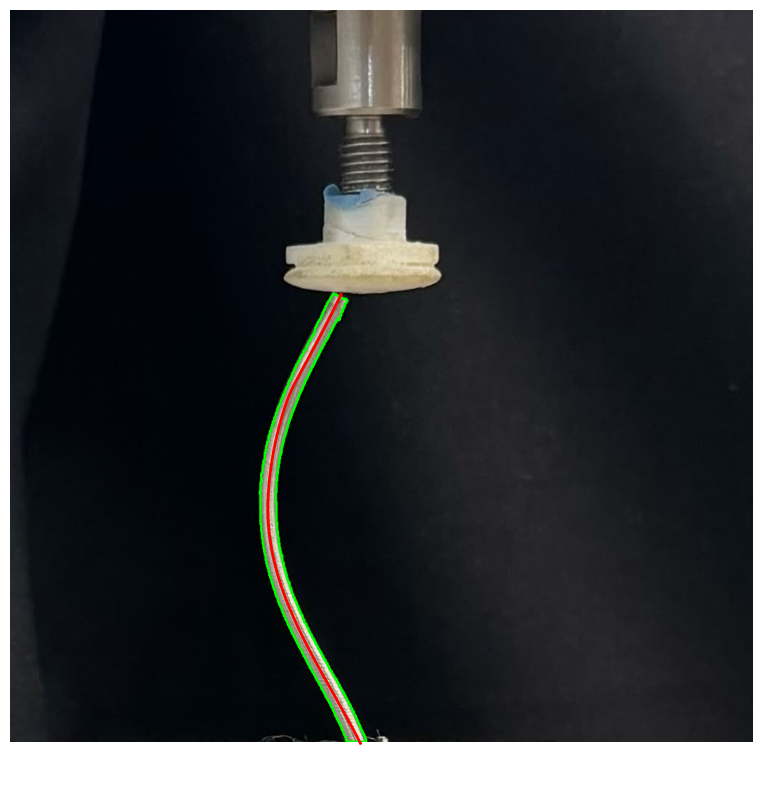

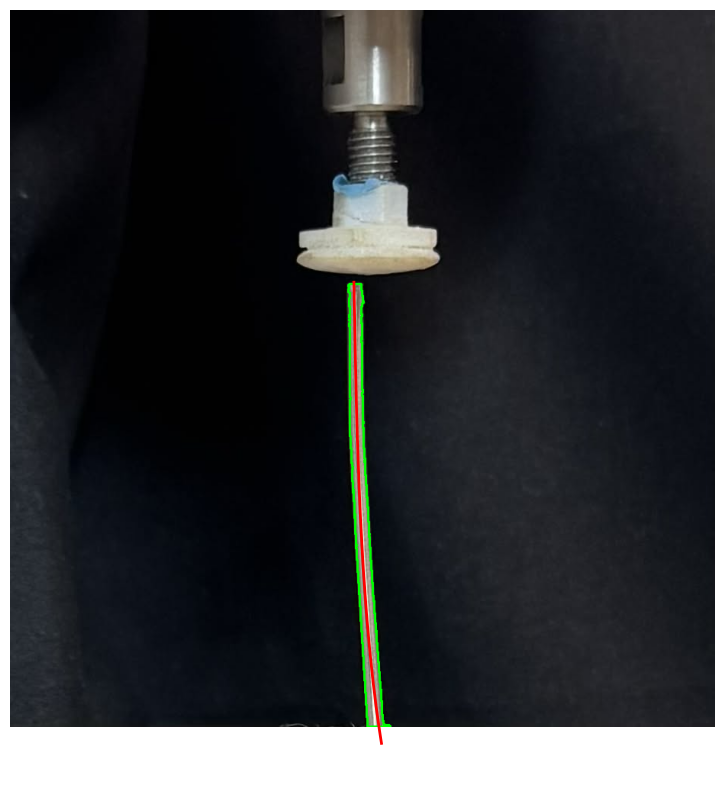

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from skimage.morphology import skeletonize

image_list = ['test.jpg','test2.jpg']
for image in image_list:
    # Load image
    img = cv2.imread(image)  # <-- change to your filename

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold to isolate light path on dark background
    _, thresh = cv2.threshold(gray, 90, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Pick the largest contour (the path)
    contour = max(contours, key=lambda c: cv2.arcLength(c, False))

    # Draw result on original image
    output = img.copy()
    cv2.drawContours(output, [contour], -1, (0, 255, 0), 2) 

    # Draw filled contour on empty image
    img = np.zeros((np.shape(output)[0], np.shape(output)[1], 3), dtype=np.uint8)
    cv2.drawContours(img, [contour], -1, (255,255,255), -1)

    # Skeletonize the filled contour
    skeleton = skeletonize(img[:,:,0] > 0)
    ys, xs = np.where(skeleton) 
    order = np.argsort(ys)
    xs, ys = xs[order], ys[order]

    # Fit a spline to skeleton points
    tck, u = splprep([xs, ys], s=1e4)

    # Evaluate spline at 200 points
    u_fine = np.linspace(0, 1, 200)
    x_fit, y_fit = splev(u_fine, tck)

    # Plot image
    output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)  # Convert to RGB
    plt.figure(figsize=(10, 10))
    plt.imshow(output_rgb)
    plt.plot(x_fit, y_fit, 'r-', linewidth=2)
    plt.axis('off')
    plt.show()
